In [1]:
# Setting personal parameters
SID4         = 5775 # last four digits of SJSU ID
SEED         = SID4        # torch.manual_seed, np.random.seed, random_state
SLICE        = SID4 % 1000   # start index of dataset subset
HP_ID        = SID4 % 6      # assigned hyperparameter arm, Table 0.1
CLS_A = SID4 % 10
CLS_B = (
    CLS_A + 1 + ((SID4 // 10) % 9)
) % 10   # two focus classes

import numpy as np
import torch
import random

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [2]:
# !pip install seaborn

In [2]:
import os
from dotenv import load_dotenv
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import html

import time
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss
)
from scipy.stats import binomtest

# Loading dataset

In [3]:
load_dotenv()

hf_token = os.getenv("HF_TOKEN")

In [4]:
data = load_dataset("fancyzhx/yelp_polarity",
                 token=hf_token)

In [5]:
data

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})

## Analyzing reviews

In [6]:
data["train"][0]

{'text': "Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.",
 'label': 0}

In [7]:
data["train"][7823]

{'text': "10 years ago I came in regularly and enjoyed.  The bar lost its self and I stopped going in completely.  Earlier this year I got a coupon and decided to walk in to take a glance at the selection.  The restaurant wasn't crowded at all, but I was shocked how fresh the food looked so I settled down to enjoy excellent cooked crab legs, cray fish, shrimp. Salt/pepper octopus..  great cooks and fresh,  also ice cold beer.  The only thing that can use help with is the sushi.  They do not do any real selection but everything else out ways the sushi.  Enjoy!!",
 'label': 1}

In [8]:
data["train"][-1]

{'text': "Ryan Rocks! I called him this morning for some sprinkler help and some potential landscaping for my backyard. He showed up to my house within an hour and answered all of my questions! When I showed him how my irrigation box was leaking, he knew right away what to do - he went a grabbed a new part out of his truck, put it on, and it was fixed! He then set up my watering timer and we talked about some landscaping and pricing. His prices seemed great and I will definitely use him in the future! To top it all off, when I asked him what I owed him for fixing my irrigation leak and his time, he said don't worry about it! I was shocked and couldn't believe his service! Thank you so much Ryan!",
 'label': 1}

**Observations**

- reviews are from different domains like medical, restaurant, service, etc
- Numbers that could have meaning like . Rating is given as "2 stars" in first review
- Long review text
- Some bold text in between review. Example review 12 . No space between the words

# 2.1 Data Preprocessing

In [9]:
# extracting train and test datasets

train_df = data["train"].to_pandas()
test_df = data["test"].to_pandas()

In [10]:
train_df.shape, test_df.shape

((560000, 2), (38000, 2))

In [11]:
train_df.columns, test_df.columns

(Index(['text', 'label'], dtype='str'), Index(['text', 'label'], dtype='str'))

In [12]:
# checking datatype of features
train_df.dtypes, test_df.dtypes

(text       str
 label    int64
 dtype: object,
 text       str
 label    int64
 dtype: object)

In [13]:
pd.set_option('display.max_colwidth', None)

In [14]:
# checking for null values
train_df.isnull().sum()

text     0
label    0
dtype: int64

In [15]:
test_df.isnull().sum()

text     0
label    0
dtype: int64

**No missing values in train and test dataframes**

In [16]:
# checking if any review is an empty string
empty_reviews = train_df[train_df['text'].str.len() == 0]

print(empty_reviews)

Empty DataFrame
Columns: [text, label]
Index: []


In [17]:
empty_reviews = test_df[test_df['text'].str.len() == 0]

print(empty_reviews)

Empty DataFrame
Columns: [text, label]
Index: []


**No review is an empty string**

In [18]:
# checking at the distribution of target variable
train_df["label"].value_counts()/train_df.shape[0]

label
0    0.5
1    0.5
Name: count, dtype: float64

**Class is balanced**

In [19]:
# Analysing review text length distribution

train_df["word_count"] = train_df["text"].str.split().str.len()
train_df["char_count"] = train_df["text"].str.len()

test_df["word_count"] = test_df["text"].str.split().str.len()
test_df["char_count"] = test_df["text"].str.len()

In [20]:
# looking at the stats
train_df[["word_count", "char_count"]].describe()

,word_count,char_count
count,560000.000000,560000.000000
mean,133.028873,726.497923
std,122.611613,669.844273
min,1.000000,1.000000
25%,51.000000,279.000000
50%,97.000000,528.000000
75%,174.000000,947.000000
max,1052.000000,5273.000000


In [21]:
# looking at the stats
test_df[["word_count", "char_count"]].describe()

,word_count,char_count
count,38000.000000,38000.000000
mean,132.558632,723.844658
std,121.216615,662.306300
min,1.000000,4.000000
25%,51.000000,280.000000
50%,97.000000,528.000000
75%,173.000000,944.000000
max,1007.000000,5107.000000


**There are reviews with one word and maximum of about 1K words. Average number of words in the review is 133. There are some reviews with 1 character.**

In [22]:
## Inspecting very short reviews
word_count = train_df["text"].str.split().str.len()
char_count = train_df["text"].str.len()

print("Reviews with 1 word or fewer:", (word_count <= 1).sum())
print("Reviews with 2 words or fewer:", (word_count <= 2).sum())
print("Reviews with 5 words or fewer:", (word_count <= 5).sum())
print("Reviews with fewer than 10 characters:", (char_count < 10).sum())

short_review_mask = word_count <= 2

print(
    train_df.loc[short_review_mask, "label"]
    .value_counts()
    .sort_index()
)

short_reviews = train_df.loc[short_review_mask, ["text", "label"]]

for _, row in short_reviews.head(20).iterrows():
    print(f"Label: {row['label']} | Review: {repr(row['text'])}")

Reviews with 1 word or fewer: 302
Reviews with 2 words or fewer: 830
Reviews with 5 words or fewer: 3861
Reviews with fewer than 10 characters: 310
label
0    416
1    414
Name: count, dtype: int64
Label: 0 | Review: 'Hoofah.'
Label: 0 | Review: 'Nope!'
Label: 0 | Review: 'ewwww'
Label: 0 | Review: 'Great'
Label: 1 | Review: 'Good food'
Label: 0 | Review: 'A'
Label: 1 | Review: 'Fabulous!'
Label: 1 | Review: 'Beer cave!!'
Label: 1 | Review: 'Fantastic martinis!!'
Label: 1 | Review: 'Awesome'
Label: 1 | Review: 'Super Sundae.'
Label: 1 | Review: 'Exquisite!!'
Label: 1 | Review: 'www.bigtsreviews.com'
Label: 0 | Review: '.'
Label: 0 | Review: 'Booooo'
Label: 0 | Review: 'Horrible!!'
Label: 0 | Review: 'Very inconsistent.'
Label: 1 | Review: 'great team,'
Label: 1 | Review: 'Good buffet!'
Label: 1 | Review: 'session key'


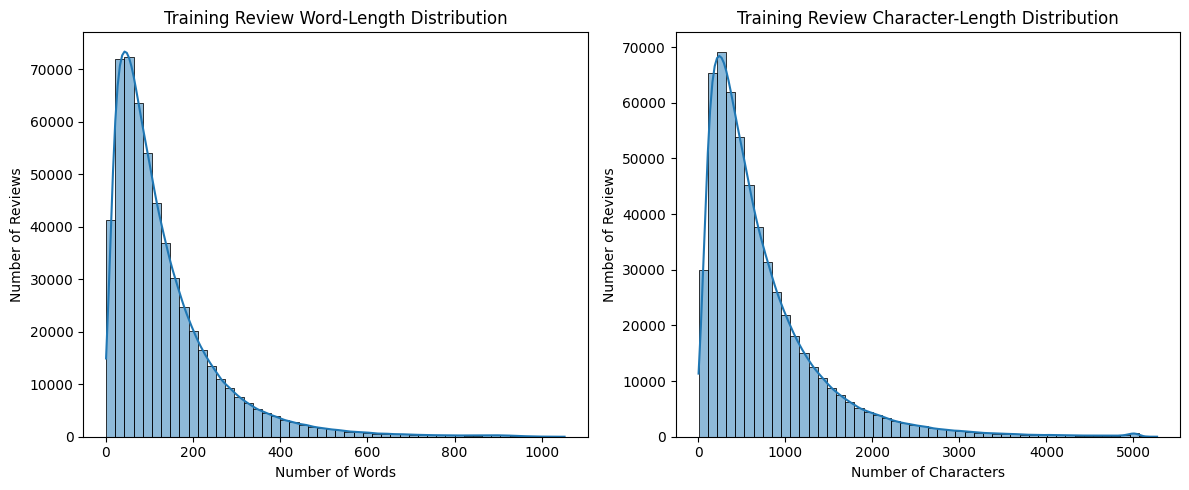

In [23]:
# plotting review-length distribution

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(train_df["word_count"], bins=50, kde=True)
plt.title("Training Review Word-Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.subplot(1, 2, 2)
sns.histplot(train_df["char_count"], bins=50, kde=True)
plt.title("Training Review Character-Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

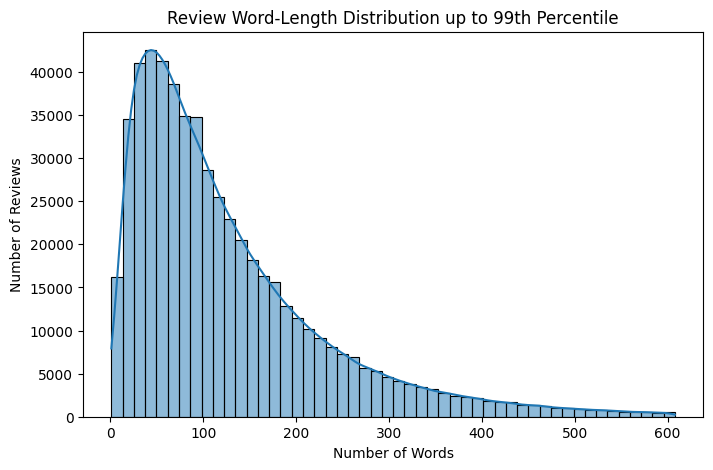

In [24]:
word_length_limit = train_df["word_count"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.histplot(
    train_df[train_df["word_count"] <= word_length_limit]["word_count"],
    bins=50,
    kde=True
)

plt.title("Review Word-Length Distribution up to 99th Percentile")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

**Data is skewed towards right, most reviews have an average of about 130 words. Some reviews have very long text wich could be outlier**

In [25]:
# checking for duplicate reviews

train_df[train_df.duplicated(subset='text')]

,text,label,word_count,char_count


In [26]:
test_df[test_df.duplicated(subset='text')]

,text,label,word_count,char_count


**No duplicate reviews**

In [27]:
# Vocabulary Analysis

## most frequent words

# Split all reviews into tokens
all_words = " ".join(train_df['text']).split()

# Count frequency
vocab_counter = Counter(all_words)

# Top 20 most common words
vocab_counter.most_common(20)

[('the', 3153980),
 ('and', 2332102),
 ('to', 1856096),
 ('I', 1838059),
 ('a', 1830796),
 ('was', 1303400),
 ('of', 1095476),
 ('for', 819468),
 ('is', 806574),
 ('in', 790415),
 ('it', 677330),
 ('that', 646987),
 ('my', 562628),
 ('with', 550316),
 ('The', 505475),
 ('but', 504894),
 ('on', 493543),
 ('you', 460144),
 ('have', 456557),
 ('this', 455149)]

**Stop words are most frequent words appearing in top 20**

In [29]:
# !pip install nltk

In [28]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/sushma/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [29]:
# removing stop words to see most common words

stop = set(stopwords.words('english'))

filtered_words = [w for w in all_words if w.lower() not in stop]
Counter(filtered_words).most_common(20)

[('place', 246716),
 ('like', 243060),
 ('get', 226489),
 ('food', 223455),
 ('would', 198553),
 ('one', 192266),
 ('good', 184507),
 ('go', 155947),
 ('time', 153320),
 ('really', 149659),
 ('back', 140429),
 ('great', 130649),
 ('service', 128051),
 ('got', 126949),
 ('even', 125523),
 ('us', 121731),
 ('-', 121044),
 ('could', 99313),
 ('also', 96697),
 ('ordered', 96539)]

**hyphen is appearing as most common words**

In [30]:
# vocabulary size

vocab_size = len(set(all_words))
print("Vocabulary size:", vocab_size)

Vocabulary size: 1446642


**Vocabulary size is huge.**

In [31]:
# class-wise vocabulary size
pos_words = " ".join(train_df[train_df['label'] == 1]['text']).split()
neg_words = " ".join(train_df[train_df['label'] == 0]['text']).split()

pos_vocab = Counter(pos_words).most_common(20)
neg_vocab = Counter(neg_words).most_common(20)

print("Top positive words:", pos_vocab)
print("Top negative words:", neg_vocab)

Top positive words: [('the', 1349280), ('and', 1095573), ('a', 856708), ('I', 735954), ('to', 706489), ('of', 506102), ('was', 496845), ('is', 436267), ('in', 352119), ('for', 351823), ('with', 271025), ('it', 270940), ('that', 239976), ('The', 238110), ('you', 229658), ('my', 220031), ('but', 216244), ('on', 212351), ('have', 202445), ('this', 183510)]
Top negative words: [('the', 1804700), ('and', 1236529), ('to', 1149607), ('I', 1102105), ('a', 974088), ('was', 806555), ('of', 589374), ('for', 467645), ('in', 438296), ('that', 407011), ('it', 406390), ('is', 370307), ('my', 342597), ('not', 294076), ('but', 288650), ('on', 281192), ('with', 279291), ('they', 277484), ('we', 273245), ('this', 271639)]


**Need to remove stop words and re-check**

In [34]:
from sklearn.feature_extraction.text import CountVectorizer

In [35]:
# # Bi-gram and tri-gram analysis


# # Bigrams
# bigram_vectorizer = CountVectorizer(ngram_range=(2,2))
# bigram_matrix = bigram_vectorizer.fit_transform(train_df['text'])

# bigram_freq = bigram_matrix.sum(axis=0).A1
# bigram_vocab = bigram_vectorizer.get_feature_names_out()

# bigram_counts = sorted(
#     list(zip(bigram_vocab, bigram_freq)),
#     key=lambda x: x[1],
#     reverse=True
# )

# bigram_counts[:20]


In [36]:
# Inspecting unusual formatting
def inspect_text_patterns(df, name):
    text = df["text"].fillna("").astype(str)

    print(f"\n{name}")
    print("-" * 40)

    print("Reviews with uppercase letters:",
          text.str.contains(r"[A-Z]").sum())

    print("Reviews with newline characters:",
          text.str.contains(r"[\r\n]").sum())

    print("Reviews with URLs:",
          text.str.contains(r"https?://|www\.", case=False, regex=True).sum())

    print("Reviews with Markdown bold markers:",
          text.str.contains(r"\*\*").sum())

    print("Reviews with repeated punctuation:",
          text.str.contains(r"[!?]{2,}|\.{2,}", regex=True).sum())

    print("Reviews with non-ASCII characters:",
          text.str.contains(r"[^\x00-\x7F]", regex=True).sum())

    print("Reviews with HTML entities:",
          text.str.contains(r"&[#a-zA-Z0-9]+;", regex=True).sum())


inspect_text_patterns(train_df, "Training set")
inspect_text_patterns(test_df, "Testing set")


Training set
----------------------------------------
Reviews with uppercase letters: 553719
Reviews with newline characters: 0
Reviews with URLs: 2755
Reviews with Markdown bold markers: 3291
Reviews with repeated punctuation: 193680
Reviews with non-ASCII characters: 0
Reviews with HTML entities: 27

Testing set
----------------------------------------
Reviews with uppercase letters: 37541
Reviews with newline characters: 0
Reviews with URLs: 190
Reviews with Markdown bold markers: 233
Reviews with repeated punctuation: 13133
Reviews with non-ASCII characters: 0
Reviews with HTML entities: 2


**There are some URL's so cannot clean all special characters**

In [37]:
# Checking for emojis


ascii_emoticon_pattern = re.compile(
    r"(?<!\w)(?::|;|=|8)(?:-)?(?:\)|\(|D|P|p|/|\\|\||"
    r"\*|정)|"
    r"(?<!\w)<3",
    flags=re.IGNORECASE
)

text = train_df["text"].fillna("").astype(str)

train_df["ascii_emoticons"] = text.apply(
    lambda review: ascii_emoticon_pattern.findall(review)
)

reviews_with_emoticons = train_df[
    train_df["ascii_emoticons"].str.len() > 0
]

print("Reviews containing ASCII emoticons:",
      len(reviews_with_emoticons))

print("\nEmoticon counts:")
print(
    Counter(
        emoticon.lower()
        for emoticons in train_df["ascii_emoticons"]
        for emoticon in emoticons
    )
)

Reviews containing ASCII emoticons: 25707

Emoticon counts:
Counter({':)': 12215, ':(': 3942, ';)': 2248, ':-)': 1824, '8p': 1533, '=)': 1137, ':\\': 775, ':d': 769, '8/': 681, ':/': 668, ':p': 571, ':-(': 531, ';-)': 467, '8)': 390, '=(': 287, '=\\': 267, '8\\': 233, ':-/': 167, '=p': 160, '=/': 160, '=d': 122, ';p': 84, ';(': 65, ':-d': 63, ';\\': 60, ':-p': 59, ';d': 45, ':-|': 25, ':|': 23, ';-(': 20, '8-p': 19, ';/': 17, ':*': 14, ':-\\': 14, '=-)': 12, ';-p': 10, '8(': 9, '8d': 8, '8-)': 8, ';-d': 6, '8-d': 5, '=-d': 4, ';-/': 3, '=|': 3, '=-(': 3, '8*': 3, '8-(': 2, '=*': 2, ';|': 2, '=-p': 1, '8-|': 1, ';*': 1, '8-/': 1})


**There are ASCII emotions which cannot be removed. Need to normalize them later.
Preserve punctuations as they contain sentiment information.**

# Data Preparation

**Lemmatization was not applied. Since the embeddings are learned from scratch, preserving original word forms can retain sentiment-relevant distinctions such as tense and intensity. The model vocabulary will be constructed from the cleaned training text only**

In [34]:
# Keeping negation words because they carry sentiment:"not good" must not become just "good".
negation_words = {
    "no", "nor", "not", "never", "none", "nobody", "nothing",
    "neither", "nowhere", "cannot", "can't", "won't", "isn't",
    "wasn't", "don't", "doesn't", "didn't", "shouldn't", "wouldn't",
    "couldn't", "haven't", "hasn't", "hadn't"
}

# Words that should not be removed because they may affect sentiment
important_words = negation_words | {
    "very", "too", "so", "out"
}

stop_words = set(stopwords.words("english")) - important_words

# Convert common text emoticons into sentiment-bearing tokens before punctuation/special-character removal.
emoticon_replacements = [
    (
        r"(?<!\w)(?::|;|=|8)\s*-?\s*(?:\)|D)(?!\w)",
        " positiveemoticon "
    ),
    (
        r"(?<!\w)(?::|;|=|8)\s*-?\s*(?:\(|/|\\)(?!\w)",
        " negativeemoticon "
    ),
    (
        r"(?<!\w)<3(?!\w)",
        " positiveemoticon "
    ),
]

# there are some reviews with rating info, so preserving them
RATING_WORDS = {
    "1": "one",
    "2": "two",
    "3": "three",
    "4": "four",
    "5": "five"
}


In [35]:
def clean_review(text):
    """Applying text-preprocessing pipeline to one review text"""

    text = str(text)

    # Decode entities before processing apostrophes/contractions.
    text = html.unescape(text)

    # Remove literal escaped characters such as "\n", "\t", and "\r".
    text = re.sub(r"\\[nrt]", " ", text, flags=re.IGNORECASE)

    # Expand contractions to preserve negation meaning.
    contractions = {
        r"\bwon't\b": "will not",
        r"\bcan't\b": "cannot",
        r"\bshan't\b": "shall not",
        r"\bain't\b": "is not",
        r"\b(\w+)n't\b": r"\1 not",
        r"\b(\w+)'re\b": r"\1 are",
        r"\b(\w+)'ve\b": r"\1 have",
        r"\b(\w+)'ll\b": r"\1 will",
        r"\b(\w+)'d\b": r"\1 would",
        r"\b(\w+)'m\b": r"\1 am",
        r"\b(\w+)'s\b": r"\1 is",
    }

    for pattern, replacement in contractions.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    # Preserve explicit numeric ratings as sentiment-bearing text tokens.
    # Examples: "2 stars" -> "ratingtwostar"; "5-star" -> "ratingfivestar"
    text = re.sub(
        r"\b([1-5])\s*(?:out\s+of\s+(?:5|five)\s*)?[-\s]*stars?\b",
        lambda match: f" rating{RATING_WORDS[match.group(1)]}star ",
        text,
        flags=re.IGNORECASE
    )

    # Remove URLs.
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Preserve ASCII emoticon sentiment before punctuation removal.
    for pattern, replacement in emoticon_replacements:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    text = text.lower()

    # Retain alphabetic tokens only; other numbers and special characters are removed.
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove stopwords while retaining negation words.
    tokens = [word for word in text.split() if word not in stop_words]

    return " ".join(tokens) if tokens else "emptyreview"

In [36]:
# applying review cleaning function on train and test
train_df["clean_text"] = train_df["text"].apply(clean_review)
test_df["clean_text"] = test_df["text"].apply(clean_review)

print("Empty placeholders in training set:",
      (train_df["clean_text"] == "emptyreview").sum())

print("\nOriginal review:")
print(train_df.loc[0, "text"])

print("\nCleaned review:")
print(train_df.loc[0, "clean_text"])

Empty placeholders in training set: 34

Original review:
Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.

Cleaned review:
unfortunately frustration dr goldberg patient repeat experience so many doctors nyc good doctor terrible staff seems staff simply never answers phone usually takes hours repeated calling get answer time wants deal run problem many doctors not get office workers patients medical nee

In [37]:
# Saving cleaned train and test dataframes

train_df.to_parquet("cleaned_train_df.parquet", index=False)
test_df.to_parquet("cleaned_test_df.parquet", index=False)

In [38]:
# Train-validation split

from sklearn.model_selection import train_test_split

train_split_df, val_df = train_test_split(
    train_df[["clean_text", "label"]],
    test_size=0.10,          # 56,000 validation reviews
    stratify=train_df["label"],
    random_state=SEED
)

# Reset indices to avoid carrying original dataset indices forward
train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

In [39]:
print("Training split:", train_split_df.shape)
print("Validation split:", val_df.shape)
print("Official test set:", test_df[["clean_text", "label"]].shape)

print("\nClass proportions")
print("Training:\n", train_split_df["label"].value_counts(normalize=True).sort_index())
print("Validation:\n", val_df["label"].value_counts(normalize=True).sort_index())
print("Test:\n", test_df["label"].value_counts(normalize=True).sort_index())

Training split: (504000, 2)
Validation split: (56000, 2)
Official test set: (38000, 2)

Class proportions
Training:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
Validation:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
Test:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [40]:
# Saving the processed datasets

train_split_df.to_parquet("train_processed.parquet", index=False)
val_df.to_parquet("val_processed.parquet", index=False)
test_df.to_parquet("test_processed.parquet", index=False)

### Tokenize the reviews at word level

In [2]:
import pandas as pd

# Load only one split at a time
train_df = pd.read_parquet(
    "train_processed.parquet",
    columns=["clean_text", "label"]
)

val_df = pd.read_parquet(
    "val_processed.parquet",
    columns=["clean_text", "label"]
)

In [3]:
def prepare_model_split(df, split_name):
    original_size = len(df)

    # Remove reviews that became empty
    df = df[df["clean_text"] != "emptyreview"].copy()

    # Remove texts appearing with conflicting labels
    label_counts = (
        df.groupby("clean_text")["label"]
        .nunique()
    )

    conflicting_texts = label_counts[label_counts > 1].index

    conflict_rows = df["clean_text"].isin(
        conflicting_texts
    ).sum()

    df = df[
        ~df["clean_text"].isin(conflicting_texts)
    ].copy()

    # Keep one copy of each cleaned text
    before_deduplication = len(df)

    df = df.drop_duplicates(
        subset="clean_text",
        keep="first"
    ).reset_index(drop=True)

    duplicates_removed = before_deduplication - len(df)

    print(f"\n{split_name}")
    print("Original rows:", original_size)
    print("Conflicting rows removed:", conflict_rows)
    print("Duplicate rows removed:", duplicates_removed)
    print("Remaining rows:", len(df))

    return df


train_df = prepare_model_split(train_df, "Training")
val_df = prepare_model_split(val_df, "Validation")


Training
Original rows: 504000
Conflicting rows removed: 111
Duplicate rows removed: 395
Remaining rows: 503463

Validation
Original rows: 56000
Conflicting rows removed: 3
Duplicate rows removed: 12
Remaining rows: 55982


In [4]:
training_texts = set(train_df["clean_text"])

overlap_mask = val_df["clean_text"].isin(training_texts)
overlap_count = overlap_mask.sum()

val_df = val_df[~overlap_mask].reset_index(drop=True)

print("Train-validation overlaps removed:", overlap_count)

print("\nTraining class balance:")
print(train_df["label"].value_counts(normalize=True).sort_index())

print("\nValidation class balance:")
print(val_df["label"].value_counts(normalize=True).sort_index())

Train-validation overlaps removed: 63

Training class balance:
label
0    0.499876
1    0.500124
Name: proportion, dtype: float64

Validation class balance:
label
0    0.500009
1    0.499991
Name: proportion, dtype: float64
